# Checking the record before the paper — `eval.py` demo

This notebook is the **assembly step** (`eval.py`) of a zero-new-data audit of an iteration-2 research record. The research question
is whether *concepts spread once adopters make them*. Before the paper is written, every number in the draft is checked against the
file that produced it. The audit has four work packages:

| WP | What it checks | Output read by `eval.py` |
|----|----------------|--------------------------|
| **WP1** | Claims ledger: 246 draft numbers, each re-read from its source file by key path (MATCH / MISMATCH / MISLABELLED / FILE_FLAG_OVERRIDDEN) | `claims_ledger.csv`, `results/wp1_summary.json` |
| **WP2** | Refit bootstrap CIs for iteration-1 deltas (T3) and a trace of every Exp6 "next field" headline number (T4) | `results/t3_refit_bootstrap.json`, `record_tables/next_field_trace.json` |
| **WP3** | Agreement of the Exp5 and Exp6 concept frames on 628 shared concepts (onset, home field, O2r, retention) | `frame_agreement.json`, the two `frame_concepts.csv` files |
| **WP4** | O5, an external-recognition outcome (Wikipedia, Wikidata, taxonomies), plus a 100-item hand check | `results/o5_validation_core.json`, `results/o5_handcheck_summary.json`, `record_tables/o5_concept_panel.csv`, `record_tables/o5_handcheck_items_final.csv` |

The original `eval.py` can re-run each work package as a subprocess (`--stages all`). Its default action is to **assemble**: it reads
the stage outputs and builds `eval_out.json` (schema `exp_eval_sol_out`), which holds aggregate metrics (`metrics_agg`) and six
per-example datasets. **This notebook runs that assembly step.** The stage outputs it reads are bundled in `mini_demo_data.json`:
* the JSON inputs are included whole;
* the CSV inputs are cut to at most 100 curated rows each.

Metrics taken from the JSON inputs therefore match the full run exactly. Counts computed from the CSV rows (the ledger status counts
and the dataset sizes) describe the demo subset.

## Setup
### Install dependencies
`loguru` is not pre-installed on Colab, so it is always installed. The core scientific packages are installed only outside Colab, at Colab's exact versions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

### Imports
This is the original import block of `eval.py`. The local module `import common as C` is replaced by a notebook cell further down. `io`, `types` and `matplotlib` are added for the notebook.

In [2]:
from __future__ import annotations

import argparse
import json
import math
import subprocess
import sys

import numpy as np
import pandas as pd
from loguru import logger

# notebook additions
import io
import types
from pathlib import Path
import matplotlib.pyplot as plt

### Data loading
The notebook fetches `mini_demo_data.json` from GitHub (for Colab) and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-3/evaluation-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("JSON inputs:", list(data["json_files"]))
print("CSV inputs :", {k: len(pd.read_csv(io.StringIO(v))) for k, v in data["csv_files"].items()}, "(rows available)")

Inputs for eval.py assemble() (iteration-3 record audit). JSON inputs bundled whole; CSV inputs as raw CSV text, row-subsets of <=100 rows each (claims ledger: all 22 non-MATCH rows + 78 MATCH rows; 100 Exp5/Exp6 shared concepts; 100 O5 panel concepts stratified by group x O5_main; all 100 hand-check items).
JSON inputs: ['frame_agreement.json', 'o5_definitions.json', 'results/o5_validation_core.json', 'results/o5_handcheck_summary.json', 'results/t3_refit_bootstrap.json', 'record_tables/next_field_trace.json', 'results/wp1_summary.json']
CSV inputs : {'claims_ledger.csv': 100, 'exp5/frame_concepts.csv': 100, 'exp6/results/frame_concepts.csv': 100, 'record_tables/o5_concept_panel.csv': 100, 'record_tables/o5_handcheck_items_final.csv': 100} (rows available)


## Config
The only tunable parameters are the numbers of CSV rows used per input table. The assembly step does no model fitting and no
resampling: the bootstrap CIs were computed upstream with B=2000 and are only read here. The runtime is a few seconds at any size.

**Original (full-run) sizes:** 246 ledger rows, 628 shared Exp5/Exp6 concepts, 12,499 O5 panel concepts and 100 hand-check items.
The bundled mini data holds at most 100 rows per table, so 100 is the largest setting that uses all of it.

In [5]:
N_LEDGER_ROWS = 100       # claims_ledger.csv rows (original: 246; bundled: 100 = all 22 non-MATCH + 78 MATCH rows)
N_SHARED_CONCEPTS = 100   # Exp5/Exp6 shared concepts for frame agreement (original: 628; bundled: 100)
N_PANEL_ROWS = 100        # O5 concept panel rows (original: 12,499; bundled: 100, stratified by group x O5_main)
N_HANDCHECK_ITEMS = 100   # hand-check items (original: 100; bundled: 100)
OUT_DIR = Path("demo_outputs")   # where eval_out.json / o5_validation.json / inputs_manifest.json are written

## Shared helpers (`common.py`, the parts `eval.py` uses)
`eval.py` calls a local module `common` as `C`. This cell copies the helpers it needs **unchanged**: `rel`, `norm_id`, `jsonable`,
`dump` and `setup_logging`, with the constant `SEED`. Only the file access differs:
* `C.read_csv(name)` returns the config-trimmed DataFrame parsed from the bundled CSV text, not a file on disk;
* `C.WS` (the workspace) points to `OUT_DIR`, so the files `eval.py` writes go there.

The frame-concept tables are trimmed together. The notebook keeps the first `N_SHARED_CONCEPTS` Exp6 concepts and the Exp5 rows for
the same concept IDs.

In [6]:
WS = OUT_DIR.resolve()
ROOT = WS
SEED = 20260928
B_MAIN = 2000
RES = WS / "results"
TAB = WS / "record_tables"
LOGS = WS / "logs"
for _d in (WS, RES, TAB, LOGS):
    _d.mkdir(parents=True, exist_ok=True)


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")


def rel(p: Path | str) -> str:
    """Path relative to ROOT (never absolute in outputs); workspace files relative to the workspace."""
    p = Path(p).resolve()
    try:
        return str(p.relative_to(WS))
    except ValueError:
        pass
    try:
        return str(p.relative_to(ROOT))
    except ValueError:
        return p.name


def norm_id(x) -> str | None:
    """Exp5 integer 37253 -> 'C37253'; Exp6 'https://openalex.org/C739882' -> 'C739882'; 'C...' unchanged."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return None
    s = str(x).strip()
    if "/" in s:
        s = s.rstrip("/").split("/")[-1]
    if s.upper().startswith("C"):
        s = s[1:]
    if s.endswith(".0"):
        s = s[:-2]
    assert s.isdigit(), f"bad concept id {x!r}"
    return "C" + str(int(s))


def jsonable(o):
    if isinstance(o, dict):
        return {str(k): jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [jsonable(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return jsonable(o.tolist())
    if isinstance(o, Path):
        return rel(o)
    return o


def dump(obj, path: Path) -> None:
    path.write_text(json.dumps(jsonable(obj), indent=1))


# --- notebook replacement for file reads: bundled CSV text -> DataFrame, trimmed by the config
_csv = {k: pd.read_csv(io.StringIO(v)) for k, v in data["csv_files"].items()}
_f6 = _csv["exp6/results/frame_concepts.csv"].head(N_SHARED_CONCEPTS)
_keep_ids = set(_f6.concept_id.map(norm_id))
_f5 = _csv["exp5/frame_concepts.csv"]
_TABLES = {
    "claims_ledger.csv": _csv["claims_ledger.csv"].head(N_LEDGER_ROWS),
    "exp5/frame_concepts.csv": _f5[_f5.concept_id.map(norm_id).isin(_keep_ids)],
    "exp6/results/frame_concepts.csv": _f6,
    "record_tables/o5_concept_panel.csv": _csv["record_tables/o5_concept_panel.csv"].head(N_PANEL_ROWS),
    "record_tables/o5_handcheck_items_final.csv": _csv["record_tables/o5_handcheck_items_final.csv"].head(N_HANDCHECK_ITEMS),
}


def read_csv(name: str) -> pd.DataFrame:
    return _TABLES[name].reset_index(drop=True).copy()


C = types.SimpleNamespace(WS=WS, ROOT=ROOT, SEED=SEED, B_MAIN=B_MAIN, RES=RES, TAB=TAB, LOGS=LOGS, setup_logging=setup_logging,
                          rel=rel, norm_id=norm_id, jsonable=jsonable, dump=dump, read_csv=read_csv,
                          E5="exp5", E6="exp6")
{k: len(v) for k, v in _TABLES.items()}

{'claims_ledger.csv': 100,
 'exp5/frame_concepts.csv': 100,
 'exp6/results/frame_concepts.csv': 100,
 'record_tables/o5_concept_panel.csv': 100,
 'record_tables/o5_handcheck_items_final.csv': 100}

## Stage list and small formatters (original code)
`STAGES` lists the work-package scripts that `eval.py --stages all` would run before assembling. **The notebook does not run them.**
They read the raw iteration-1 and iteration-2 artifacts, which are hundreds of MB, and the hand-check step calls an LLM and
Wikipedia. The list is kept for reference.

Two helpers are used below:
* `s()` serialises any value to a string, the format the `exp_eval_sol_out` schema expects for `input` and `output`;
* `num()` returns a finite float or `None`.

In [7]:
STAGES = [["wp2_t3_refit.py"], ["wp2_t4_nextfield.py"], ["wp3_frames.py"], ["wp4_extract.py"], ["wp4_o5.py"],
          ["wp4_handcheck.py", "--finalize"], ["wp1_ledger.py"]]


def s(x) -> str:
    if isinstance(x, float) and not math.isfinite(x):
        return "NaN"
    return x if isinstance(x, str) else json.dumps(C.jsonable(x))


def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None

## `main()` → logging setup
The original `main()` parses `--stages` and runs the stages if it is set to `all`, then calls `assemble()`. The notebook runs only
the logging setup. The body of `assemble()` is split over the cells below and runs at top level, with the same statements in the same
order.

In [8]:
C.setup_logging("eval")

## Assemble step 1 — read the stage outputs
This step loads each work package's output. It also writes the combined `o5_validation.json`: the O5 core validation plus the hand
check. File reads now come from `data["json_files"]` (JSON) and `C.read_csv` (CSV), not from disk.

In [9]:
J = data["json_files"]
led = C.read_csv("claims_ledger.csv")                         # was: pd.read_csv(C.WS / "claims_ledger.csv")
fa = J["frame_agreement.json"]                                # was: json.loads((C.WS / "frame_agreement.json").read_text())
core = J["results/o5_validation_core.json"]
hc = J["results/o5_handcheck_summary.json"]
t3 = J["results/t3_refit_bootstrap.json"]
tr = J["record_tables/next_field_trace.json"]
wp1 = J["results/wp1_summary.json"]
defs = J["o5_definitions.json"]
o5v = {"definitions_file": "o5_definitions.json", **core, "hand_check": hc}
C.dump(o5v, C.WS / "o5_validation.json")
ag = fa["agreement"]
main = core["associations_pooled_heldout_DL"]["O5_main"]
st = led.status.value_counts().to_dict()
blocking_rows = led[led.severity == "blocking"]
print("ledger status counts (demo subset):", st, "| blocking rows:", len(blocking_rows))

ledger status counts (demo subset): {'MATCH': 78, 'MISLABELLED': 15, 'MISMATCH': 6, 'FILE_FLAG_OVERRIDDEN': 1} | blocking rows: 34


## Assemble step 2 — aggregate metrics (`metrics_agg`)
This step builds the flat dictionary of headline numbers:
* **ledger counts**: MATCH, MISMATCH, MISLABELLED and blocking rows, where `n_blocking_fixed` counts blocking rows that carry a
  correction or a text-change note;
* **WP3 frame agreement**: onset, home-field kappa, O2r Spearman and Lin CCC, episode Jaccard, and retention kappa under the original
  and the matched `R_abs2` rule;
* **WP4 O5 validation**: base rates, pooled DerSimonian–Laird Spearman correlations with the publication outcomes and their CIs, and
  hand-check precision, false-negative rate and date accuracy;
* **WP2**: the reproduced next-field likelihood ratios, and the point estimate and 95% refit-bootstrap CI for each iteration-1 delta
  (`t3_*`).

Non-numeric values are dropped, and dots and dashes in keys are replaced with `_`.

In [10]:
ma = {"n_ledger_rows": len(led), "n_match": st.get("MATCH", 0), "n_rounding": st.get("ROUNDING", 0), "n_mismatch": st.get("MISMATCH", 0),
      "n_missing": st.get("MISSING", 0) + st.get("MISSING_SOURCE", 0), "n_mislabelled": st.get("MISLABELLED", 0),
      "n_file_flag_overridden": st.get("FILE_FLAG_OVERRIDDEN", 0),
      "n_blocking_rows": len(blocking_rows),
      "n_blocking_fixed": int(blocking_rows.correction_text.fillna("").str.len().gt(0).sum() + blocking_rows.text_change_note.fillna("").str.len().gt(0).sum()
                              - (blocking_rows.correction_text.fillna("").str.len().gt(0) & blocking_rows.text_change_note.fillna("").str.len().gt(0)).sum()),
      "n_draft_numbers_harvested": sum(wp1["harvest"].values()), "n_draft_numbers_auto_matched": wp1["harvest"].get("AUTO_MATCH", 0),
      "t1_n_portability_indicators": wp1["T1_n_indicators"], "n_partial_association_candidates": wp1["n_partial_candidates"],
      "frame_n_exp5": fa["n_exp5"], "frame_n_exp6": fa["n_exp6"], "frame_n_both": fa["n_both"],
      "onset_exact_agree": ag["onset_exact"]["value"], "onset_pm1_agree": ag["onset_pm1"]["value"],
      "home_kappa": ag["home_kappa_26"]["value"], "o1_kappa": ag["O1_kappa"]["value"], "o3_kappa": ag["O3_kappa"]["value"],
      "o2r_spearman": ag["O2r_m50"]["spearman"], "o2r_m50_lin_ccc": ag["O2r_m50"]["lin_ccc"],
      "early_volume_log_spearman": ag["early_volume_log"]["spearman"], "episode_jaccard_median": ag["episode_jaccard"]["median"],
      "episode_jaccard_pooled": ag["episode_jaccard"]["pooled"], "retention_kappa": ag["retention"]["kappa_R_vs_Rcj"],
      "retention_kappa_R_abs2_matched_definition": ag["retention"]["kappa_R_abs2_vs_Rcj"],
      "pooling_criteria_met": fa["pooling"]["n_met"],
      "o5_main_base_rate_heldout": core["base_rate_heldout"], "o5_main_base_rate_all": next(r["O5_main_rate"] for r in core["coverage_by_group"] if r["group"] == "ALL"),
      "o5_rho_O2r_pooled": main["rho_O2r_m50"]["pooled"], "o5_rho_O2r_pooled_ci_lo": main["rho_O2r_m50"]["ci95"][0],
      "o5_rho_O2r_pooled_ci_hi": main["rho_O2r_m50"]["ci95"][1], "o5_rho_O1_pooled": main["rho_O1"]["pooled"],
      "o5_rho_O1_pooled_ci_lo": main["rho_O1"]["ci95"][0], "o5_rho_O1_pooled_ci_hi": main["rho_O1"]["ci95"][1],
      "o5_rho_O2r_resid_pooled": main["rho_O2r_resid"]["pooled"], "o5_rho_logN_pooled": main["rho_log_N_outcome"]["pooled"],
      "o5_tax_rho_O2r_pooled": core["associations_pooled_heldout_DL"]["O5_tax"]["rho_O2r_m50"]["pooled"],
      "o5_share_recognised_at_or_before_t0": core["lag"]["_all_main_sources"]["n_excluded_recognised_at_or_before_t0"] / core["n_frame"],
      "o5_pos_precision": hc["positive_precision_strict"], "o5_pos_precision_lenient": hc["positive_precision_lenient_partial_counts"],
      "o5_neg_fn_rate": hc["negatives_false_negative_rate"], "o5_date_error_le1_share": hc["date_error_le_1y_share_all_checked"],
      "o5_executor_llm_kappa": hc["executor_vs_llm_kappa_same_concept"], "o5_fit_for_use": int(hc["FIT_FOR_USE"]),
      "llm_cost_usd": hc["llm"]["llm_cost_usd"],
      "next_field_LR_M1_vs_M0_reproduced": tr["trace"]["LR_M1_vs_M0_breslow"]["recomputed"],
      "next_field_LR_M2_vs_M0_reproduced": tr["trace"]["LR_M2_vs_M0_breslow"]["recomputed"],
      "next_field_LR_M2_vs_M0_exact": tr["trace"]["LR_M2_vs_M0_exact"]["recomputed"],
      "next_field_trace_matches": tr["n_trace_match"], "next_field_trace_checked": tr["n_trace_checked"]}
for r in t3:
    k = r["row"].replace(".", "_")
    ma[f"t3_{k}_point"] = r["point_reproduced"]
    ma[f"t3_{k}_ci95_lo"] = r["ci95_refit"][0]
    ma[f"t3_{k}_ci95_hi"] = r["ci95_refit"][1]
ma = {k.replace("-", "_").replace(".", "_"): float(v) for k, v in ma.items() if num(v) is not None}
print(len(ma), "metrics")

74 metrics


## Assemble step 3 — per-example datasets: claims ledger, refit bootstrap, next-field trace
Each dataset is a list of examples with `input`, `output`, `predict_*`, `metadata_*` and `eval_*` fields.
* **claims_ledger** has one example per draft claim. `output` is the value re-read from the source file, `predict_status` is the audit
  verdict, and `eval_match = 1` for MATCH or ROUNDING.
* **refit_bootstrap_iter1** covers each iteration-1 delta. It pairs the reported point estimate and its fixed-prediction 90% CI with
  the refit bootstrap (B=2000), and reports the CI width and the widening ratio.
* **next_field_trace** covers each Exp6 headline number: the reported value against the recomputed one.

In [11]:
ds = []
ex = []
for r in led.itertuples():
    e = {"input": s({"claim_id": r.claim_id, "draft_section": r.draft_section, "claim_text": r.claim_text, "quantity": r.quantity,
                     "reported_value": r.reported_value}),
         "output": s(r.source_value), "predict_status": str(r.status),
         "metadata_source_file": s(r.source_file), "metadata_key_path": s(r.key_path), "metadata_severity": r.severity,
         "metadata_artifact_id": r.artifact_id, "metadata_in_draft": bool(r.in_draft),
         "metadata_correction": s(r.correction_text) if isinstance(r.correction_text, str) else "",
         "eval_match": 1.0 if r.status in ("MATCH", "ROUNDING") else 0.0}
    if num(r.abs_diff) is not None:
        e["eval_abs_diff"] = float(r.abs_diff)
    ex.append(e)
ds.append({"dataset": "claims_ledger", "examples": ex})
ex = []
for r in t3:
    ex.append({"input": s({"row": r["row"], "experiment": r["experiment"], "outcome": r["outcome"], "base": r["base_cols"], "cand": r["cand_cols"]}),
               "output": s({"point_reported": r["point_reported"], "fixed_prediction_ci90": r["fixed_prediction_ci90"]}),
               "predict_refit_bootstrap": s({"point": r["point_reproduced"], "ci90": r["ci90_refit"], "ci95": r["ci95_refit"], "B": r["B"]}),
               "metadata_source_file": r["source_file"], "metadata_key_path": r["key_path"],
               "eval_point_abs_diff": float(r["abs_diff"]), "eval_ci95_width": float(r["ci95_refit"][1] - r["ci95_refit"][0]),
               **({"eval_ci_widening_ratio_90": float(r["ci_widening_ratio_90"])} if num(r["ci_widening_ratio_90"]) is not None else {})})
ds.append({"dataset": "refit_bootstrap_iter1", "examples": ex})
ex = []
for k, v in tr["trace"].items():
    e = {"input": s({"quantity": k, "how": v.get("how")}), "output": s(v.get("reported")), "predict_recomputed": s(v.get("recomputed")),
         "metadata_source_file": s(v.get("source_file")), "metadata_key_path": s(v.get("key_path"))}
    if v.get("match") is not None:
        e["eval_match"] = 1.0 if v["match"] else 0.0
    ex.append(e)
ds.append({"dataset": "next_field_trace", "examples": ex})
print([(d["dataset"], len(d["examples"])) for d in ds])

[('claims_ledger', 100), ('refit_bootstrap_iter1', 7), ('next_field_trace', 32)]


## Assemble step 4 — frame agreement per shared concept (WP3)
The two experiments built their concept frames independently. Exp5 stores concept IDs as integers and Exp6 as OpenAlex URLs, so
`norm_id` maps both to the `C<digits>` form before the inner join. For each shared concept the example records:
* whether the onset year `t0` agrees exactly, and the absolute difference;
* whether the primary home field agrees. Exp5's `home` may list several fields separated by `;` or `|`, and the first one is used.

In [12]:
# frame agreement per shared concept
f5 = C.read_csv("exp5/frame_concepts.csv")                    # was: C.read_csv(C.E5 / "frame_concepts.csv")
f6 = C.read_csv("exp6/results/frame_concepts.csv")            # was: C.read_csv(C.E6 / "results/frame_concepts.csv")
f5["id"] = f5.concept_id.map(C.norm_id)
f6["id"] = f6.concept_id.map(C.norm_id)
m = f5.merge(f6, on="id", suffixes=("_5", "_6"))
ex = []
for r in m.itertuples():
    h5 = int(float(str(r.home_5).replace("|", ";").split(";")[0]))
    ex.append({"input": s({"concept": r.id, "name": r.name_5, "exp5_split": r.split_5, "exp6_split": r.split_6}),
               "output": s({"t0": r.t0_6, "home_primary": int(r.home_primary), "O2r_m50": r.O2r_m50}),
               "predict_exp5_frame": s({"t0": r.t0_5, "home_primary": h5, "early_volume": r.early_volume}),
               "metadata_group_exp5": r.group_5, "metadata_group_exp6": r.group_6,
               "eval_onset_exact": float(r.t0_5 == r.t0_6), "eval_onset_abs_diff": float(abs(r.t0_5 - r.t0_6)),
               "eval_home_agree": float(h5 == int(r.home_primary))})
ds.append({"dataset": "frame_agreement_shared_concepts", "examples": ex})
print("shared concepts:", len(m))

shared concepts: 100


## Assemble step 5 — O5 external recognition per concept (WP4)
There is one example per concept in the Exp5 frame. `output` holds the publication outcomes: O1, the relative spread O2r_m50 and O3.
The `predict_*` fields hold three O5 variants:
* **main**: all main sources;
* **wiki**: Wikipedia and Wikidata only;
* **tax**: curated taxonomies such as MeSH, ACM CCS and MSC.

`eval_O5_lag` is the number of years from literature onset to first recognition, when one exists.

In [13]:
# O5 per concept (Exp5 frame)
pan = C.read_csv("record_tables/o5_concept_panel.csv")        # was: C.read_csv(C.TAB / "o5_concept_panel.csv")
ex = []
for r in pan.itertuples():
    e = {"input": s({"concept": r.id, "name": r.name, "t0": int(r.t0), "group": r.gkey}),
         "output": s({"O1": r.O1, "O2r_m50": r.O2r_m50, "O3": r.O3}),
         "predict_O5_main": str(int(r.O5_main)), "predict_O5_wiki": str(int(r.O5_wiki)), "predict_O5_tax": str(int(r.O5_tax)),
         "metadata_split": r.split, "eval_O5_main": float(r.O5_main)}
    if num(r.O5_lag) is not None:
        e["eval_O5_lag"] = float(r.O5_lag)
    ex.append(e)
ds.append({"dataset": "o5_exp5_frame", "examples": ex})
print("O5 panel concepts:", len(pan))

O5 panel concepts: 100


## Assemble step 6 — the 100-item O5 hand check (WP4)
The sample has 50 positives (O5 says "recognised") and 50 negatives. The LLM verdict and the executor's hand verdict are both
recorded.
* A **positive** is correct if the final verdict is that the external entry is the *same concept*.
* A **negative** is a false negative if recognition did in fact exist.

In [14]:
it = C.read_csv("record_tables/o5_handcheck_items_final.csv")  # was: C.read_csv(C.TAB / "o5_handcheck_items_final.csv")
ex = []
for r in it.itertuples():
    e = {"input": s({"item": r.item, "kind": r.kind, "concept": r.id, "name": r.name, "t0": r.t0, "source": r.source,
                     "entry_title": r.entry_title, "year": r.year}),
         "output": s({"final_same": getattr(r, "final_same", None), "final_fn": getattr(r, "final_fn", None)}),
         "predict_llm_same_concept": s(r.llm_same_concept), "predict_executor_same_concept": s(r.exec_same),
         "metadata_wiki_first_rev_year": s(r.wiki_first_rev_year), "metadata_bucket": r.bucket}
    if r.kind == "positive" and isinstance(getattr(r, "final_same", None), str):
        e["eval_positive_correct"] = 1.0 if r.final_same == "yes" else 0.0
    if r.kind == "negative" and isinstance(getattr(r, "final_fn", None), str):
        e["eval_false_negative"] = 1.0 if r.final_fn == "yes" else 0.0
    ex.append(e)
ds.append({"dataset": "o5_hand_check", "examples": ex})
print("hand-check items:", len(it))

hand-check items: 100


## Assemble step 7 — metadata and write `eval_out.json`
This step adds provenance and the readings of each work package to the metadata, then writes `eval_out.json`:
* the ledger status counts and the frame-pooling decision;
* the Exp5-minus-Exp6 note and the O5 readings;
* the resolutions of the next-field clashes;
* the full refit table.

It also merges the per-stage input manifests (sha256 of every file read) into `inputs_manifest.json`. The listing of
`record_tables/` and the manifests come from the bundled data.

In [15]:
meta = {"evaluation_name": "Checking the record before the paper (iteration-3 record audit)",
        "plan_id": "gen_plan_evaluation_1_idx4", "resampling_unit": "concept", "bootstrap": {"B": 2000, "seed": C.SEED},
        "path_convention": "source paths are relative to the run's 3_invention_loop directory; workspace outputs relative to this workspace",
        "dependencies": ["art_wxWssKSUR45f", "art_N-mpomDZZ1ln", "art_O7Dq4L02QnDN"],
        "read_by_path": ["art_lwI2DuRtQRZX", "iter_1 exp1/exp3/exp4", "iter_2 paper_draft.md", "iter_2 review_report"],
        "ledger_status_counts": st, "frame_agreement": {k: fa[k] for k in ("n_exp5", "n_exp6", "n_both", "pooling", "disagreement_attribution")},
        "exp5_minus_exp6": fa["exp5_minus_exp6"], "o5_readings": {v: p["reading"] for v, p in core["associations_pooled_heldout_DL"].items()},
        "o5_hand_check": {k: v for k, v in hc.items() if not isinstance(v, list)}, "o5_definitions": defs,
        "next_field_clashes": {k: tr[k] for k in ("strata_clash_resolution", "LR_clash_resolution", "d_clash_resolution")},
        "t3_refit": t3, "record_tables": data["record_tables_listing"],   # was: sorted(p.name for p in C.TAB.iterdir())
        "files": ["claims_ledger.csv", "frame_agreement.json", "o5_validation.json", "o5_definitions.json", "text_corrections.md",
                  "inputs_manifest.json", "record_tables/"]}
out = {"metadata": C.jsonable(meta), "metrics_agg": ma, "datasets": ds}
(C.WS / "eval_out.json").write_text(json.dumps(C.jsonable(out), indent=1))
# combined inputs manifest
man = {}
for name in sorted(data["inputs_manifests"]):                 # was: for p in sorted(C.RES.glob("inputs_manifest_*.json"))
    man.update(data["inputs_manifests"][name])
(C.WS / "inputs_manifest.json").write_text(json.dumps(dict(sorted(man.items())), indent=1))
logger.info(f"eval_out.json: {len(ma)} metrics, datasets {[ (d['dataset'], len(d['examples'])) for d in ds]}")

21:25:05|INFO   |eval_out.json: 74 metrics, datasets [('claims_ledger', 100), ('refit_bootstrap_iter1', 7), ('next_field_trace', 32), ('frame_agreement_shared_concepts', 100), ('o5_exp5_frame', 100), ('o5_hand_check', 100)]


## Results
The tables and figure below show:
* **(a)** the claims-ledger verdicts in the demo subset;
* **(b)** the refit-bootstrap 95% CIs for the iteration-1 deltas. None of them excludes 0;
* **(c)** Exp5/Exp6 frame agreement. The metrics agree closely except **retention**, whose kappa is 0.28 under the original rule and
  0.98 once the absolute `R_abs2` rule is matched;
* **(d)** the O5 hand check and O5's pooled correlation with the publication outcomes, which is about 0 (O5 is unrelated to them).

The last table compares each headline metric in this run with the full run (`reference_full_run` in the data file). Metrics read from
JSON inputs match it exactly. Counts computed from CSV rows reflect the demo subset.

The curated subsets are not random samples, so their per-example means differ from the full run:
* the shared-concept subset includes **every** concept whose onset year differs between Exp5 and Exp6, so the demo's per-example
  `eval_onset_exact` is lower than the full run's 0.976;
* the ledger subset includes every non-MATCH row;
* the O5 panel is stratified by group × O5_main.

                                           this demo  full run   same
n_ledger_rows                               100.0000  246.0000  False
n_match                                      78.0000  224.0000  False
n_mismatch                                    6.0000    6.0000   True
n_mislabelled                                15.0000   15.0000   True
n_blocking_rows                              34.0000   58.0000  False
frame_n_both                                628.0000  628.0000   True
onset_exact_agree                             0.9761    0.9761   True
home_kappa                                    0.9897    0.9897   True
o2r_spearman                                  0.9977    0.9977   True
retention_kappa                               0.2801    0.2801   True
retention_kappa_R_abs2_matched_definition     0.9796    0.9796   True
o5_main_base_rate_heldout                     0.2375    0.2375   True
o5_rho_O2r_pooled                             0.0138    0.0138   True
o5_rho_O1_pooled    

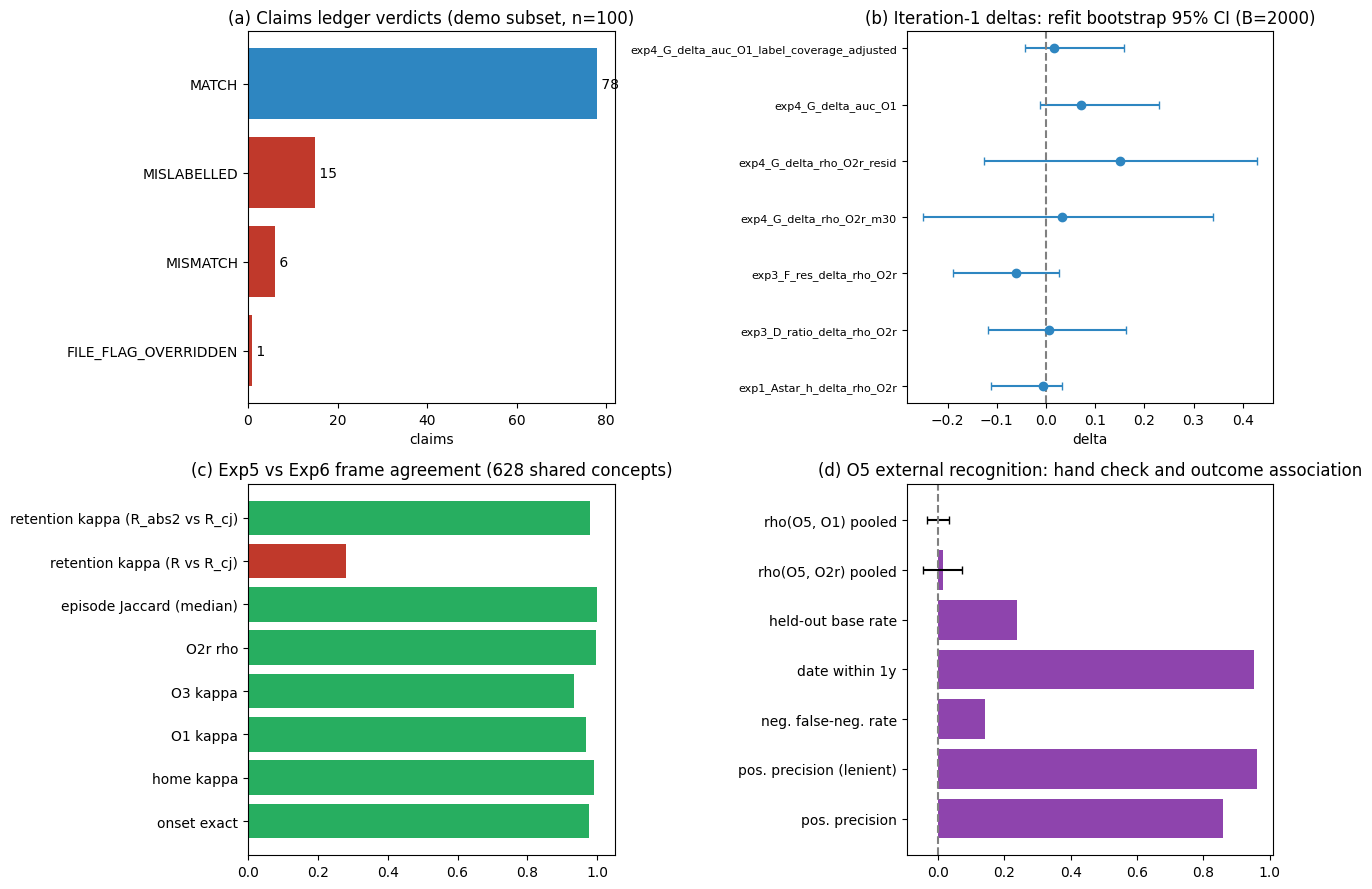

In [16]:
ref = data["reference_full_run"]
# --- key metrics vs the full run
keys = ["n_ledger_rows", "n_match", "n_mismatch", "n_mislabelled", "n_blocking_rows", "frame_n_both", "onset_exact_agree", "home_kappa",
        "o2r_spearman", "retention_kappa", "retention_kappa_R_abs2_matched_definition", "o5_main_base_rate_heldout", "o5_rho_O2r_pooled",
        "o5_rho_O1_pooled", "o5_pos_precision", "o5_neg_fn_rate", "o5_date_error_le1_share", "next_field_LR_M1_vs_M0_reproduced",
        "next_field_LR_M2_vs_M0_reproduced", "next_field_LR_M2_vs_M0_exact", "next_field_trace_matches", "llm_cost_usd"]
tbl = pd.DataFrame({"this demo": [ma.get(k) for k in keys], "full run": [ref["metrics_agg"].get(k) for k in keys]}, index=keys)
tbl["same"] = np.isclose(tbl["this demo"].astype(float), tbl["full run"].astype(float))
print(tbl.round(4).to_string())
print()
print(pd.DataFrame({"this demo": {d["dataset"]: len(d["examples"]) for d in ds}, "full run": ref["dataset_sizes"]}).to_string())

# --- per-dataset eval means computed from the examples just assembled
def _mean(dname, key):
    v = [e[key] for d in ds if d["dataset"] == dname for e in d["examples"] if key in e]
    return (float(np.mean(v)) if v else float("nan")), len(v)
print()
for dname, key in [("claims_ledger", "eval_match"), ("next_field_trace", "eval_match"), ("frame_agreement_shared_concepts", "eval_onset_exact"),
                   ("frame_agreement_shared_concepts", "eval_home_agree"), ("o5_exp5_frame", "eval_O5_main"),
                   ("o5_hand_check", "eval_positive_correct"), ("o5_hand_check", "eval_false_negative")]:
    mu, n = _mean(dname, key)
    print(f"{dname:34s} {key:24s} mean={mu:.3f} (n={n})")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# (a) ledger status
ax = axes[0, 0]
sc = pd.Series(st).sort_values()
ax.barh(sc.index, sc.values, color=["#c0392b" if k != "MATCH" else "#2e86c1" for k in sc.index])
for i, v in enumerate(sc.values):
    ax.text(v, i, f" {v}", va="center")
ax.set_title(f"(a) Claims ledger verdicts (demo subset, n={len(led)})")
ax.set_xlabel("claims")
# (b) refit bootstrap CIs (forest plot)
ax = axes[0, 1]
rows = [r["row"] for r in t3]
pt = [r["point_reproduced"] for r in t3]
lo = [r["ci95_refit"][0] for r in t3]
hi = [r["ci95_refit"][1] for r in t3]
y = np.arange(len(rows))
ax.errorbar(pt, y, xerr=[np.subtract(pt, lo), np.subtract(hi, pt)], fmt="o", color="#2e86c1", capsize=3)
ax.axvline(0, color="grey", ls="--")
ax.set_yticks(y, rows, fontsize=8)
ax.set_title("(b) Iteration-1 deltas: refit bootstrap 95% CI (B=2000)")
ax.set_xlabel("delta")
# (c) frame agreement
ax = axes[1, 0]
fk = {"onset exact": "onset_exact_agree", "home kappa": "home_kappa", "O1 kappa": "o1_kappa", "O3 kappa": "o3_kappa",
      "O2r rho": "o2r_spearman", "episode Jaccard (median)": "episode_jaccard_median", "retention kappa (R vs R_cj)": "retention_kappa",
      "retention kappa (R_abs2 vs R_cj)": "retention_kappa_R_abs2_matched_definition"}
vals = [ma[v] for v in fk.values()]
ax.barh(list(fk), vals, color=["#c0392b" if v < 0.5 else "#27ae60" for v in vals])
ax.set_xlim(0, 1.05)
ax.set_title(f"(c) Exp5 vs Exp6 frame agreement ({int(ma['frame_n_both'])} shared concepts)")
# (d) O5 validation
ax = axes[1, 1]
ok = {"pos. precision": ma["o5_pos_precision"], "pos. precision (lenient)": ma["o5_pos_precision_lenient"],
      "neg. false-neg. rate": ma["o5_neg_fn_rate"], "date within 1y": ma["o5_date_error_le1_share"],
      "held-out base rate": ma["o5_main_base_rate_heldout"], "rho(O5, O2r) pooled": ma["o5_rho_O2r_pooled"],
      "rho(O5, O1) pooled": ma["o5_rho_O1_pooled"]}
ax.barh(list(ok), list(ok.values()), color="#8e44ad")
ax.errorbar([ma["o5_rho_O2r_pooled"], ma["o5_rho_O1_pooled"]], [5, 6],
            xerr=[[ma["o5_rho_O2r_pooled"] - ma["o5_rho_O2r_pooled_ci_lo"], ma["o5_rho_O1_pooled"] - ma["o5_rho_O1_pooled_ci_lo"]],
                  [ma["o5_rho_O2r_pooled_ci_hi"] - ma["o5_rho_O2r_pooled"], ma["o5_rho_O1_pooled_ci_hi"] - ma["o5_rho_O1_pooled"]]],
            fmt="none", color="black", capsize=3)
ax.axvline(0, color="grey", ls="--")
ax.set_title("(d) O5 external recognition: hand check and outcome association")
plt.tight_layout()
plt.show()